# Module 4 — Customization

Plots are now possible. This module is about making them readable, polished, and publication-ready.

Coming from ggplot2, this corresponds roughly to knowledge around `theme()`, `scale_*()`, `labs()`, and `annotate()`, but matplotlib splits those ideas across many small `ax.*` methods rather than one composable theme system.

The mental model:

```text
┌──────────────────────────────────────────────────────┐
│ An Axes is a collection of customizable parts.       │
│ You modify each part by calling a method on `ax`.    │
└──────────────────────────────────────────────────────┘

             ┌──── title ────┐
             │   My Plot     │      ax.set_title()
             │               │
spines ───→  │   ▲           │  ←── spines: ax.spines[...]
(the box)    │   │ • •       │
             │   │ • • •     │
             │   │   •       │  ←── annotations / text:
             │   └─────►     │      ax.annotate(), ax.text()
             │   ↑     ↑     │
             │ ticks   │     │      ax.set_xticks()
             │         │     │
             │ x-label │     │      ax.set_xlabel()
             └───────────────┘

 y-label: ax.set_ylabel()
```

The customizations below follow roughly the order they are usually added to a plot.

## 1. Titles, labels, and basic text

The basic text methods are used constantly:

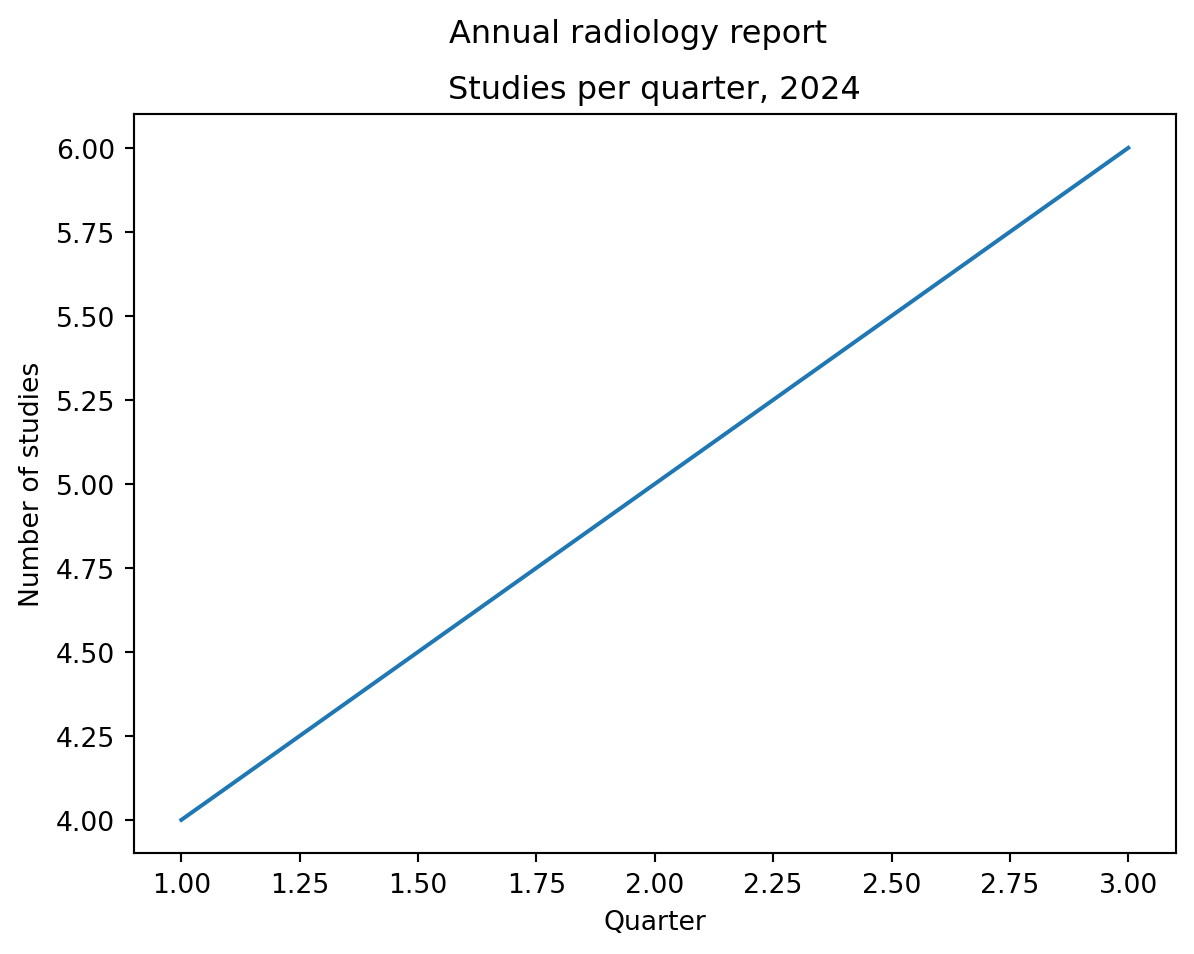

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])

ax.set_title("Studies per quarter, 2024")  # title above this axes
ax.set_xlabel("Quarter")                   # x-axis label
ax.set_ylabel("Number of studies")         # y-axis label

fig.suptitle("Annual radiology report")    # title above the whole figure
plt.show()

The distinction matters:

- `ax.set_title()` titles one panel.
- `fig.suptitle()` titles the whole figure.

This becomes especially important with multiple subplots.

Most text methods accept styling keywords:

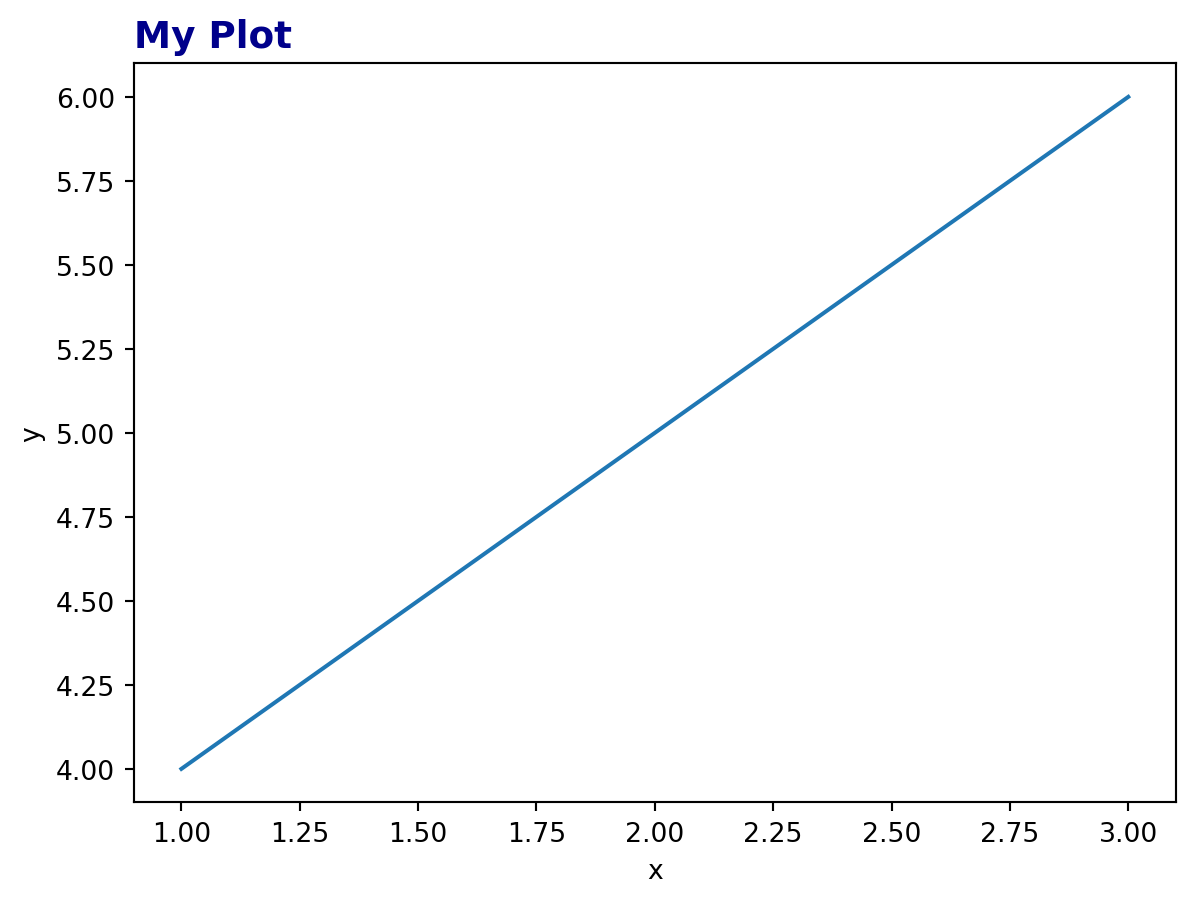

In [2]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])

ax.set_title(
    "My Plot",
    fontsize=14,
    fontweight="bold",
    color="darkblue",
    loc="left",  # "left", "center" (default), or "right"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

## 2. Axis limits and scales

Axis limits define the visible data window. Axis scales define how data values map to visual position.

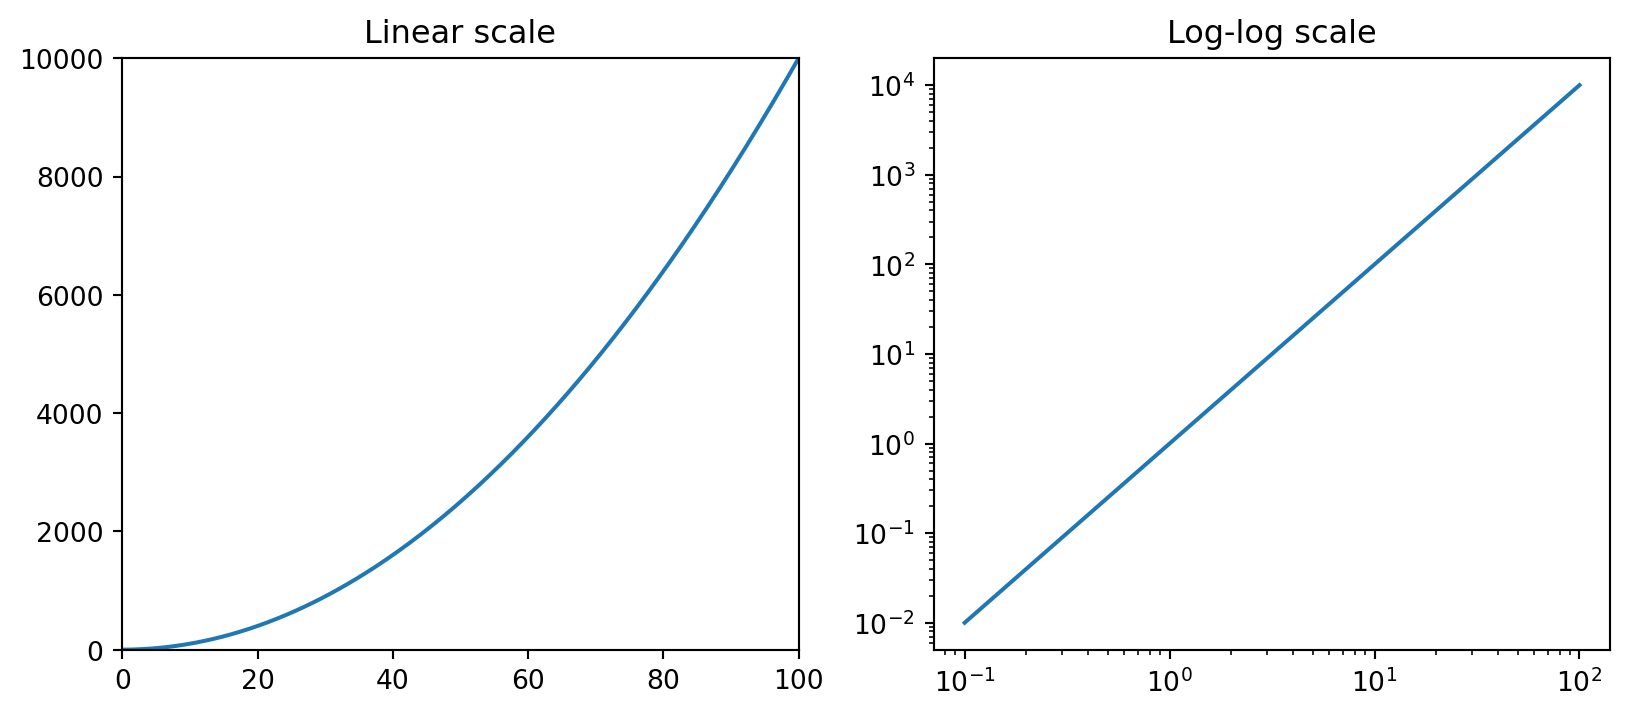

In [3]:
import numpy as np

x = np.linspace(0.1, 100, 300)
y = x ** 2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, y)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 10_000)
axes[0].set_title("Linear scale")

axes[1].plot(x, y)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Log-log scale")

plt.show()

Common methods:

```python
ax.set_xlim(0, 100)       # set x range
ax.set_ylim(-1, 1)        # set y range
ax.set_xlim(left=0)       # set only one end, leave the other automatic

ax.set_xscale("log")     # log scale on x
ax.set_yscale("log")     # log scale on y
ax.set_yscale("symlog")  # log-like scale that handles zero/negative values
```

### ggplot2 mapping

| ggplot2 | matplotlib |
|---|---|
| `+ xlim(0, 100)` | `ax.set_xlim(0, 100)` |
| `+ scale_y_log10()` | `ax.set_yscale("log")` |
| `+ coord_cartesian(...)` | `ax.set_xlim()` / `ax.set_ylim()` without dropping data |

Subtle gotcha: `set_xlim()` and `set_ylim()` do **not** filter data. They change only the visible window. The data remain present in the plot object. This is closer to ggplot2's `coord_cartesian()` than to data filtering.

## 3. Ticks: the fiddly part

Ticks are where matplotlib customization often becomes verbose.

The basic split:

```text
┌─────────────────────────────────────────────────────────┐
│ Tick locations → where the ticks appear                │
│ Tick labels    → what text shows at each tick           │
│ Tick style     → font, rotation, size, color            │
└─────────────────────────────────────────────────────────┘
```

### Setting tick positions and labels

For categorical plots, it is common to set numeric positions first, then map those positions to labels.

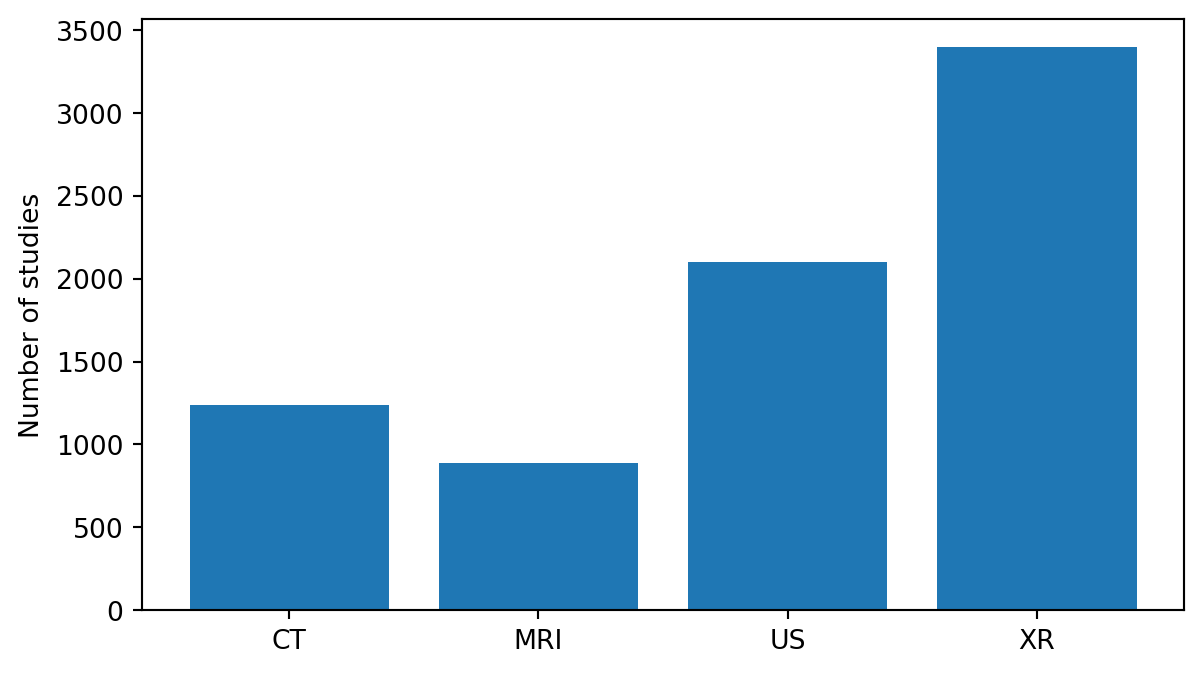

In [4]:
modalities = ["CT", "MRI", "US", "XR"]
counts = [1240, 890, 2100, 3400]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(modalities)), counts)

ax.set_xticks(range(len(modalities)))  # tick positions: [0, 1, 2, 3]
ax.set_xticklabels(modalities)         # labels at those positions
ax.set_ylabel("Number of studies")
plt.show()

Modern matplotlib (≥3.5) can set positions and labels in one call:

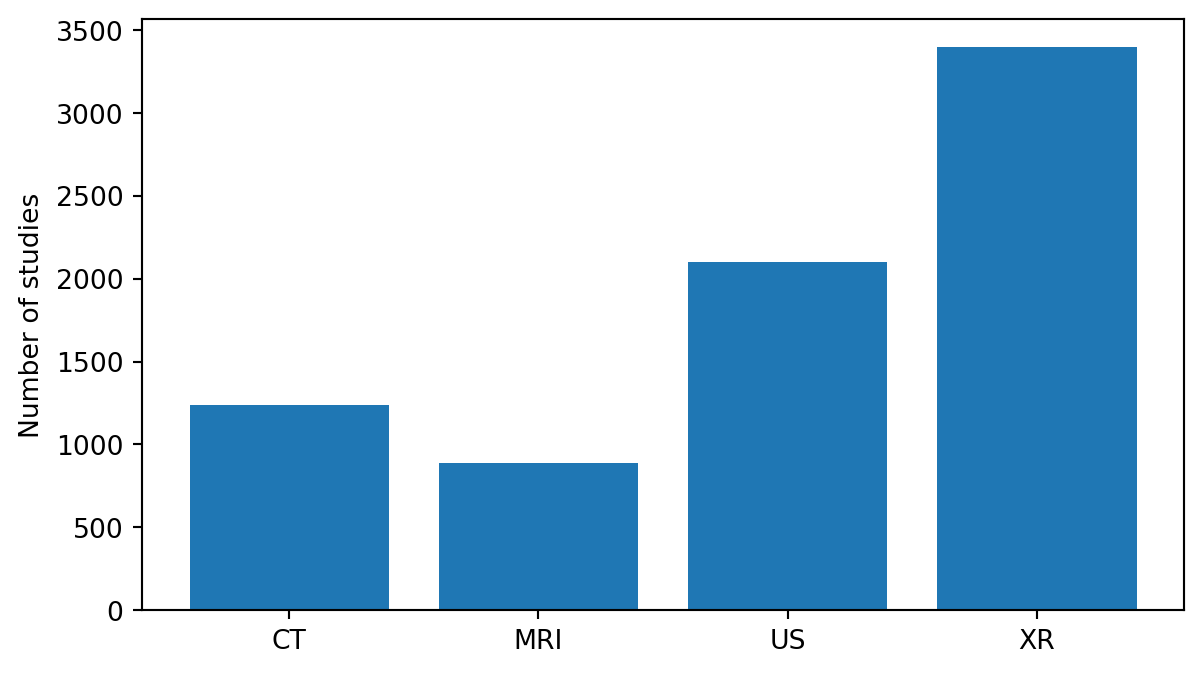

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(modalities)), counts)

ax.set_xticks(range(len(modalities)), labels=modalities)
ax.set_ylabel("Number of studies")
plt.show()

### Rotating tick labels

Rotating tick labels is very common when category names are long and overlap.

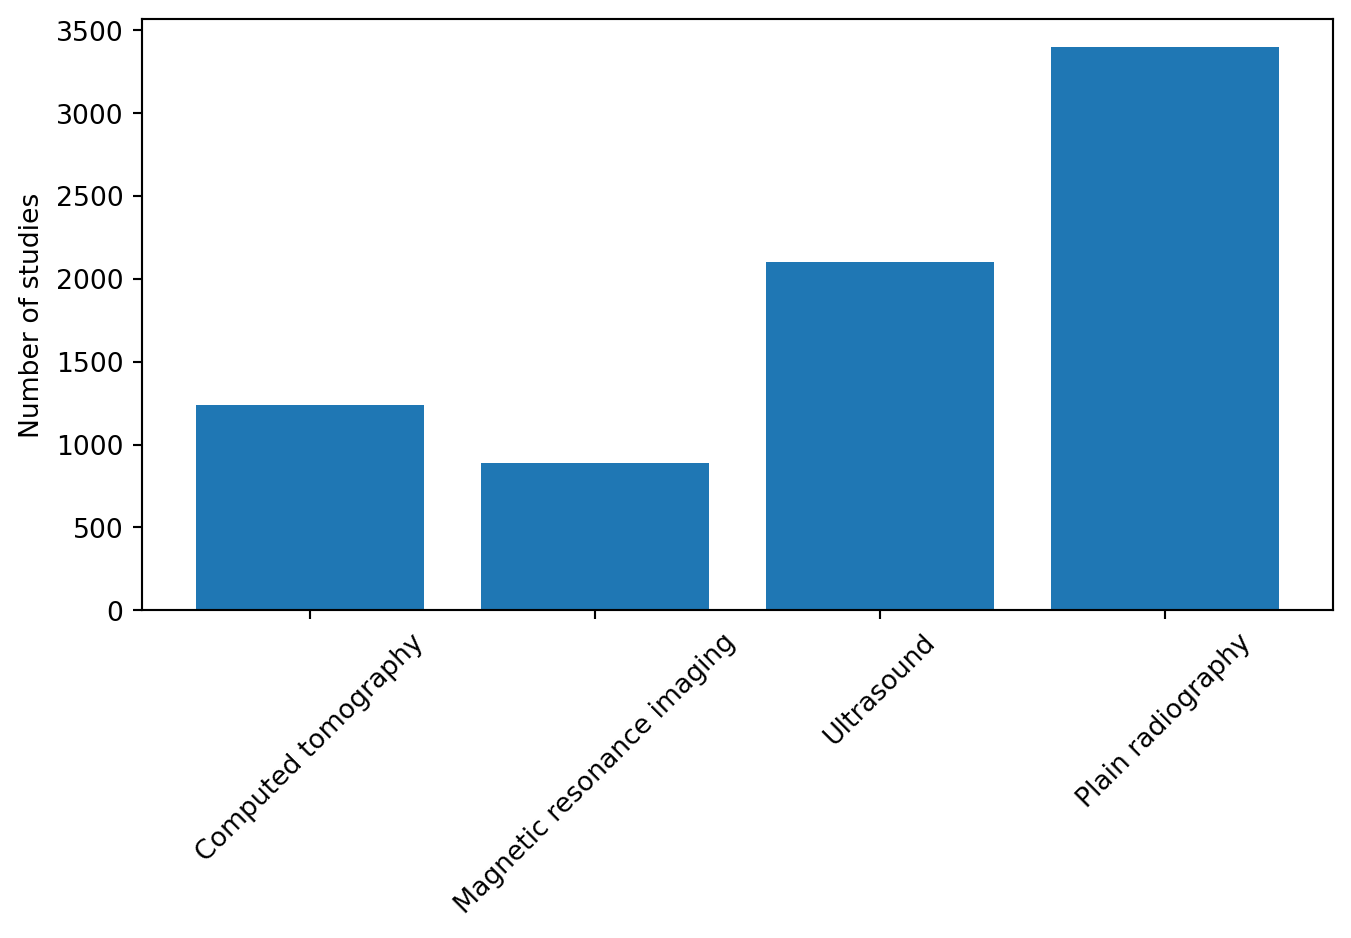

In [6]:
modalities_long = [
    "Computed tomography",
    "Magnetic resonance imaging",
    "Ultrasound",
    "Plain radiography",
]
counts = [1240, 890, 2100, 3400]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(modalities_long)), counts)
ax.set_xticks(range(len(modalities_long)), labels=modalities_long)
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Number of studies")
plt.show()

A more controlled version uses `plt.setp()` to set properties on the tick label `Text` objects:

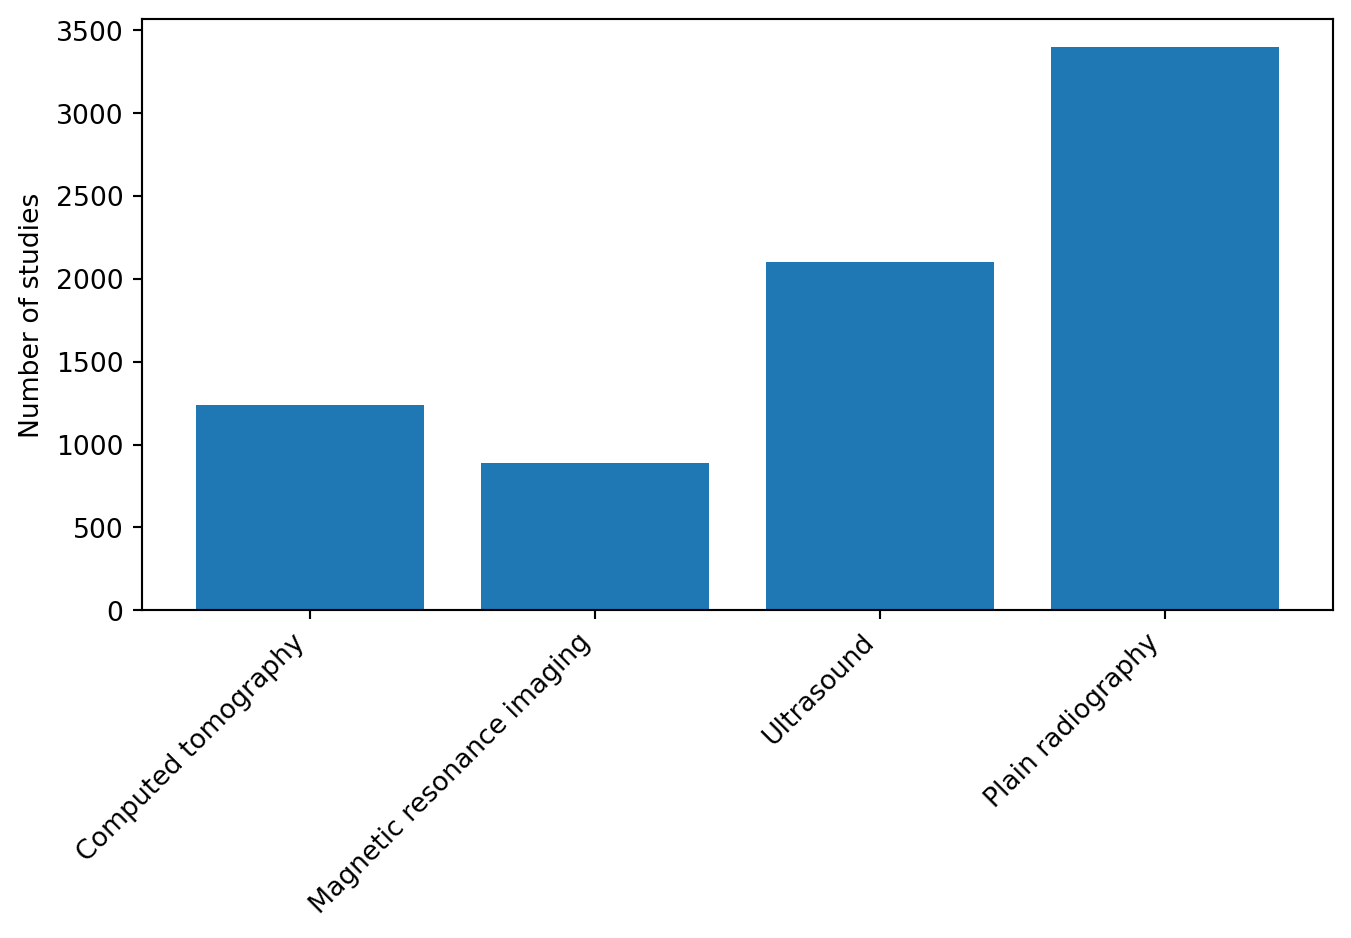

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(modalities_long)), counts)
ax.set_xticks(range(len(modalities_long)), labels=modalities_long)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylabel("Number of studies")
plt.show()